In [27]:
import numpy as np
import librosa
import soundfile as sf
import sounddevice as sd
import matplotlib.pyplot as plt

#### **1) Audio Cleaning & Processing:**

In [28]:
audio_data, sample_freq = librosa.load('Feynman.wav', duration=55.2)

In [29]:
sd.play(audio_data, sample_freq)

In [30]:
freq_domain = librosa.stft(audio_data)

magnitudes = np.abs(freq_domain)

noise_level = np.mean(magnitudes[:, :100])

cleaned_magnitudes = np.maximum(magnitudes - noise_level, 0)

cleaned_freq_domain = cleaned_magnitudes * np.exp(1j * np.angle(freq_domain))
cleaned_audio = librosa.istft(cleaned_freq_domain)

sf.write('cleaned_Feynman.wav', cleaned_audio, sample_freq)
cleaned_audio_data, cleaned_sample_freq = sf.read('cleaned_Feynman.wav')

In [31]:
sd.play(cleaned_audio_data, cleaned_sample_freq)

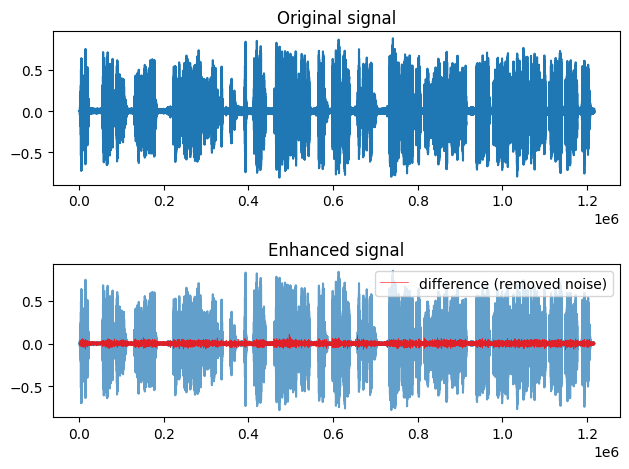

In [32]:
min_len = min(len(audio_data), len(cleaned_audio_data))

audio_data_trimmed = audio_data[:min_len]
cleaned_audio_data_trimmed = cleaned_audio_data[:min_len]

plt.subplot(2, 1, 1)
plt.plot(audio_data_trimmed)
plt.title("Original signal")

plt.subplot(2, 1, 2)
plt.plot(cleaned_audio_data_trimmed, alpha=0.7)

difference = audio_data_trimmed - cleaned_audio_data_trimmed
plt.plot(difference, color='red', label="difference (removed noise)", linewidth=0.5, alpha=0.8)

plt.title("Enhanced signal")
plt.legend(loc='upper right')

plt.tight_layout()

plt.show()

In [33]:
fft_out = np.fft.fft(cleaned_audio_data)

freqs = np.fft.fftfreq(len(cleaned_audio_data), d=1/cleaned_sample_freq)

amplitudes = np.abs(fft_out)
highest_amp = amplitudes[np.argmax(amplitudes)]
print(f"Highest amplitude: {abs(highest_amp)}")

# Find the dominant frequency (the peak)
peak_freq = freqs[np.argmax(amplitudes)]
print(f"Dominant Frequency: {abs(peak_freq)} Hz")

Highest amplitude: 2555.7530635571025
Dominant Frequency: 60.00670488010097 Hz
